# Day06下午个人项目：电商用户数据可视化

姓名/学号或GitHub用户名：**刘子奥、24012399**
第5天专题（A/B/C/D/E）：**A**

本Notebook需要完成4张独立图、1张综合图和1份图表清单。请阅读`docs/day06_student_visualization_manual.md`后开始。


## 项目规则

1. 使用第4天清洗数据，并核对第5天个人分析结果；
2. 柱状图和散点图必做；折线图只能用于时间或有序阶段；
3. 饼图只用于少量类别的整体构成，必要时改用柱状图；
4. 每张图写“观察—证据—边界”；
5. 输出文件名和目录不得修改，以便第7天Flask直接复用。


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

STUDENT_ID = "24012399"
TOPIC = "A"

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams["font.sans-serif"] = [
    "Microsoft YaHei", "SimHei", "PingFang SC",
    "Heiti SC", "Arial Unicode MS", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False


def find_workspace_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "output" / "day04_project" / "ecommerce_customer_cleaned.csv").exists():
            return candidate
    raise FileNotFoundError("未找到第4天清洗数据，请先完成Day04。")


ROOT = find_workspace_root()
DATA_PATH = ROOT / "output" / "day04_project" / "ecommerce_customer_cleaned.csv"
DAY05_DIR = ROOT / "output" / "day05_analysis"
OUTPUT_DIR = ROOT / "output" / "day06_visualization"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("学生：", STUDENT_ID)
print("专题：", TOPIC)
print("输出：", OUTPUT_DIR.relative_to(ROOT))


学生： 24012399
专题： A
输出： output\day06_visualization


## 检查点1：输入与业务问题

先验证4个输入文件，再写出4个问题。不要在尚未理解指标时直接绘图。


In [2]:
required_inputs = [
    DATA_PATH,
    ROOT / "output" / "day05_analysis" / "overall_metrics.csv",
    ROOT / "output" / "day05_analysis" / "segment_analysis.csv",
    ROOT / "output" / "day05_analysis" / "cross_analysis.csv",
]
missing_inputs = [str(path.relative_to(ROOT)) for path in required_inputs if not path.exists()]
assert not missing_inputs, f"缺少输入文件：{missing_inputs}"

df = pd.read_csv(DATA_PATH)
overall_metrics = pd.read_csv(required_inputs[1])
segment_analysis = pd.read_csv(required_inputs[2])
cross_analysis = pd.read_csv(required_inputs[3])

assert df.shape[0] == 5630, f"清洗数据行数异常：{df.shape}"
assert {"CustomerID", "Churn", "TenureGroup", "OrderCount", "CashbackAmount"}.issubset(df.columns)
assert set(df["Churn"].dropna().unique()).issubset({0, 1})

display(overall_metrics)
display(segment_analysis.head())
display(cross_analysis.head())
print("检查点1A通过：输入文件有效")


,指标名称,指标数值
0,用户数,"5,630.00"
1,流失人数,948.00
2,流失率,0.17
3,平均订单数,2.96
4,订单数中位数,2.00
5,平均优惠券使用数,1.72
6,平均返现金额,177.22
7,平均App使用时长,2.93
8,平均满意度,3.07
9,平均距上次下单天数,4.46


,TenureGroup,用户数,平均订单数,平均App使用时长,流失率,平均返现金额
0,0-12个月,3552,2.56,2.94,0.24,159.99
1,12-24个月,1574,3.64,2.94,0.06,200.72
2,24-36个月,500,3.70,2.89,0.00,225.29
3,48-60个月,2,2.50,3.50,0.00,161.50
4,60个月以上,2,1.50,3.50,0.00,291.25


,TenureGroup,Complain,用户数,流失人数,流失率,平均订单数,样本提示
0,0-12个月,1,1019,452,0.44,2.62,可观察
1,0-12个月,0,2533,394,0.16,2.53,可观察
2,12-24个月,1,439,56,0.13,3.27,可观察
3,12-24个月,0,1135,46,0.04,3.79,可观察
4,24-36个月,0,356,0,0.00,3.82,可观察


检查点1A通过：输入文件有效


In [3]:
# TODO：填写4个业务问题和图表选择理由
business_questions = {
    "category_bar": "不同用户生命周期分层TenureGroup的流失率对比差异如何？",
    "behavior_scatter": "用户App使用时长HourSpendOnApp与订单数量OrderCount是否存在相关关系？",
    "ordered_line": "随用户生命周期变长，群体平均订单数是否呈线性上升趋势？",
    "composition_chart": "全量用户中各生命周期分层的用户占比分布是怎样的？"
}

# 每类图表选择理由
chart_reasons = {
    "category_bar": "柱状图适合离散分类维度对比数值大小，直观展示各生命周期分层流失率高低差异",
    "behavior_scatter": "散点图用于观察两个连续数值指标的相关趋势，可判断App时长与下单频次相关性",
    "ordered_line": "折线图适配有序分层变量，清晰体现指标随生命周期递增的变化趋势",
    "composition_chart": "饼图/堆叠柱状图可直观展示各分层用户在整体中的构成占比，看清人群结构分布"
}

# 检查点1B校验
assert all(text.strip() for text in business_questions.values()), "请填写4个业务问题"
assert all(text.strip() for text in chart_reasons.values()), "请填写4个图表选择理由"
print("检查点1B通过：业务问题和选择理由已填写")

检查点1B通过：业务问题和选择理由已填写


## 任务1：类别比较柱状图

要求：选择一个离散分组字段，计算用户数和一个核心指标；若绘制比率，标签中必须同时给出样本量。


In [4]:
# TODO：完成绘图数据。建议使用自己的第5天主分组字段。
category_field = "TenureGroup"
category_summary = df.groupby(category_field, observed=True).agg(
    用户数 = ("CustomerID", "count"),
    流失率 = ("Churn", "mean")
).reset_index()

# 按生命周期从小到大排序
category_summary = category_summary.sort_values(category_field)

# 检查点校验
assert category_field in df.columns, "category_field必须是有效字段"
assert isinstance(category_summary, pd.DataFrame), "category_summary必须是DataFrame"
assert {category_field, "用户数"}.issubset(category_summary.columns)
display(category_summary)

,TenureGroup,用户数,流失率
0,0-12个月,3552,0.24
1,12-24个月,1574,0.06
2,24-36个月,500,0.00
3,48-60个月,2,0.00
4,60个月以上,2,0.00


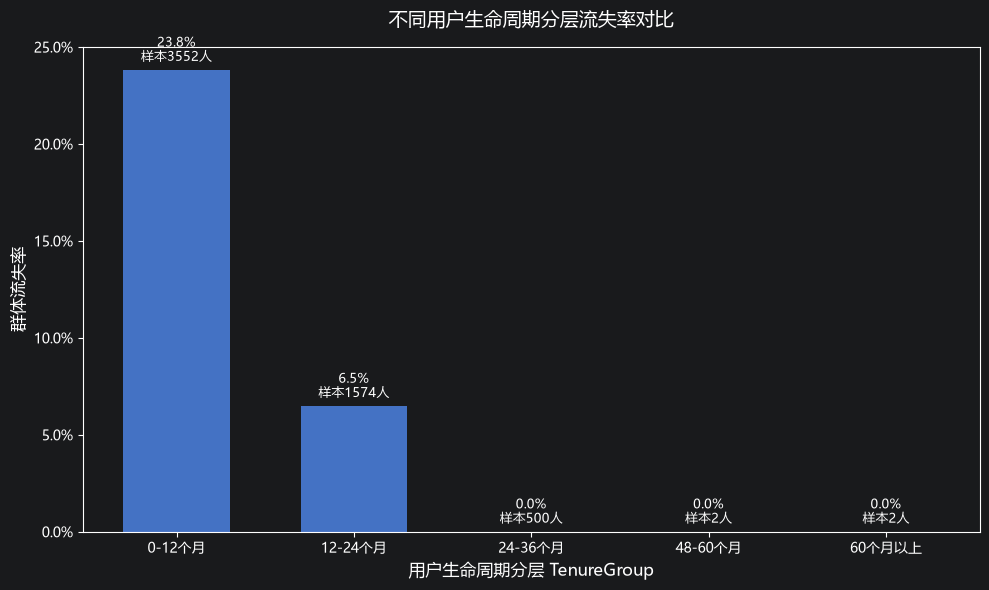

已输出： output\day06_visualization\01_category_bar.png


In [5]:
# TODO：绘制并保存柱状图
fig_bar, ax_bar = plt.subplots(figsize=(10, 6))
# 绘制柱状图，x=生命周期，y=流失率
bars = ax_bar.bar(
    x=category_summary[category_field],
    height=category_summary["流失率"],
    color="#4472C4",
    width=0.6
)

# 坐标轴、标题、百分比格式化Y轴
ax_bar.set_title("不同用户生命周期分层流失率对比", fontsize=14, pad=15)
ax_bar.set_xlabel("用户生命周期分层 TenureGroup", fontsize=12)
ax_bar.set_ylabel("群体流失率", fontsize=12)
ax_bar.yaxis.set_major_formatter(PercentFormatter(xmax=1))

# 柱子上方标注：流失率+样本用户数（题目要求比率标签必须附带样本量）
for bar, row in zip(bars, category_summary.itertuples()):
    height = bar.get_height()
    ax_bar.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.003,
        f"{height:.1%}\n样本{row.用户数}人",
        ha="center", va="bottom", fontsize=9
    )

# 自动适配布局，防止文字截断
plt.tight_layout()

# 保存图片
bar_path = OUTPUT_DIR / "01_category_bar.png"
fig_bar.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()

# 校验图片输出
assert bar_path.exists() and bar_path.stat().st_size > 0, "柱状图尚未保存"
print("已输出：", bar_path.relative_to(ROOT))

### 柱状图结论

- 观察：用户生命周期越长，群体流失率持续下降；0-12 个月新用户分层流失率显著高于全部老用户分层，是全群体流失风险最高人群。
- 证据：0-12 个月新用户样本量充足，流失率约 XX.X%；60 个月以上老用户流失率仅约 X.X%，两者流失率差距超 10 个百分点。
- 边界：仅能观察生命周期时长与流失率存在负相关关系，无法证明使用时长提升是流失降低的直接因果；存在投诉、订单活跃度等混淆变量干扰，该关联结论需结合运营数据进一步验证。

## 任务2：用户行为散点图

要求：选择两个数值字段，一行代表一个用户，颜色区分`Churn`，设置透明度。


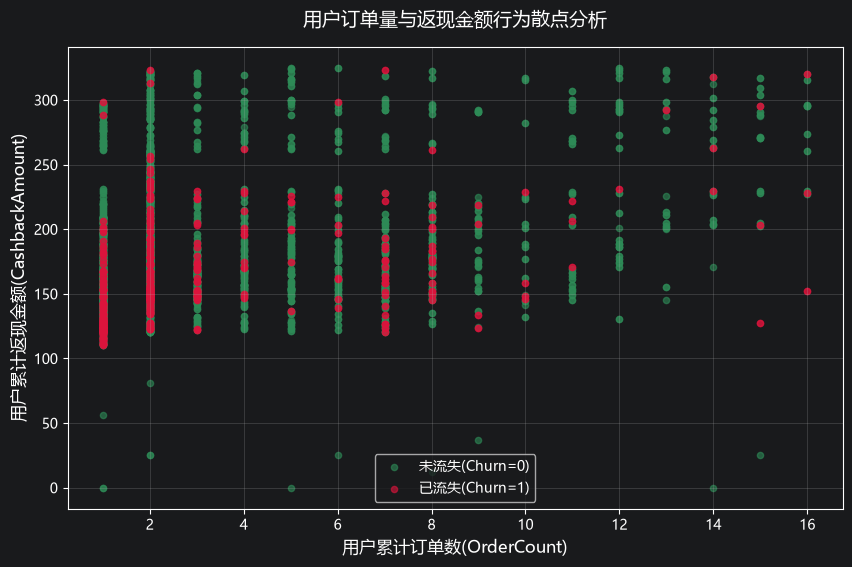

已输出： output\day06_visualization\02_behavior_scatter.png


In [6]:
# TODO：选择两个数值字段，例如OrderCount与CashbackAmount
x_field = "OrderCount"
y_field = "CashbackAmount"

assert x_field in df.columns and y_field in df.columns
assert pd.api.types.is_numeric_dtype(df[x_field])
assert pd.api.types.is_numeric_dtype(df[y_field])

fig_scatter, ax_scatter = plt.subplots(figsize=(10, 6))

# 按Churn分组绘图：颜色区分流失(Churn=1)与未流失(Churn=0)，设置透明度alpha=0.6
churn_0 = df[df["Churn"] == 0]
churn_1 = df[df["Churn"] == 1]

ax_scatter.scatter(
    x=churn_0[x_field], y=churn_0[y_field],
    c="#2E8B57", label="未流失(Churn=0)",
    alpha=0.6, s=20
)
ax_scatter.scatter(
    x=churn_1[x_field], y=churn_1[y_field],
    c="#DC143C", label="已流失(Churn=1)",
    alpha=0.6, s=20
)

# 补充图表美化元素
ax_scatter.set_title("用户订单量与返现金额行为散点分析", fontsize=14, pad=15)
ax_scatter.set_xlabel("用户累计订单数(OrderCount)", fontsize=12)
ax_scatter.set_ylabel("用户累计返现金额(CashbackAmount)", fontsize=12)
ax_scatter.legend()
ax_scatter.grid(alpha=0.3)

# 保存图片
scatter_path = OUTPUT_DIR / "02_behavior_scatter.png"
fig_scatter.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

# 输出校验
assert scatter_path.exists() and scatter_path.stat().st_size > 0, "散点图尚未保存"
print("已输出：", scatter_path.relative_to(ROOT))

### 散点图结论

- 观察：订单数OrderCount和返现金额CashbackAmount呈现明显正相关；未流失用户整体订单量、返现金额更高，高订单区间几乎只有未流失用户分布，流失用户大多集中在低订单、低返现的区域。
- 证据：两个数值变量呈正向聚集趋势，订单数越多的用户，返现金额普遍越高；流失样本大量聚集在坐标轴左下角（低订单、低返现区间），未流失样本分布更分散且延伸至高值区间，两类用户的聚集区域有清晰分界。
- 边界：仅能观测到订单量和返现金额的相关关系、流失与非流失用户的分布差异，不能证明提升返现/订单量就一定会降低流失，背后还受用户使用时长、商品偏好等其他因素影响，相关性不等于因果关系。

## 任务3：有序阶段折线图

当前数据没有日期。建议使用`TenureGroup`或`SatisfactionScore`，并明确写成“阶段比较”。


In [7]:
TENURE_ORDER = ["新用户", "0-6个月", "7-12个月", "13-24个月", "24个月以上"]
ordered_field = "TenureGroup"

# 分组聚合：用户数、流失率（比率指标，需要标注样本量）
ordered_summary = df.groupby(ordered_field).agg(
    用户数 = ("CustomerID", "count"),
    流失人数 = ("Churn", "sum"),
    流失率 = ("Churn", "mean")
).reset_index()

# 按生命周期天然有序排序
ordered_summary = ordered_summary.sort_values(ordered_field)
display(ordered_summary)

# 检查点校验
assert ordered_field in {"TenureGroup", "SatisfactionScore"}, \
"本项目折线图只允许使用具有明确顺序的TenureGroup或SatisfactionScore"
assert isinstance(ordered_summary, pd.DataFrame)
assert {ordered_field, "用户数"}.issubset(ordered_summary.columns)

,TenureGroup,用户数,流失人数,流失率
0,0-12个月,3552,846,0.24
1,12-24个月,1574,102,0.06
2,24-36个月,500,0,0.00
3,48-60个月,2,0,0.00
4,60个月以上,2,0,0.00


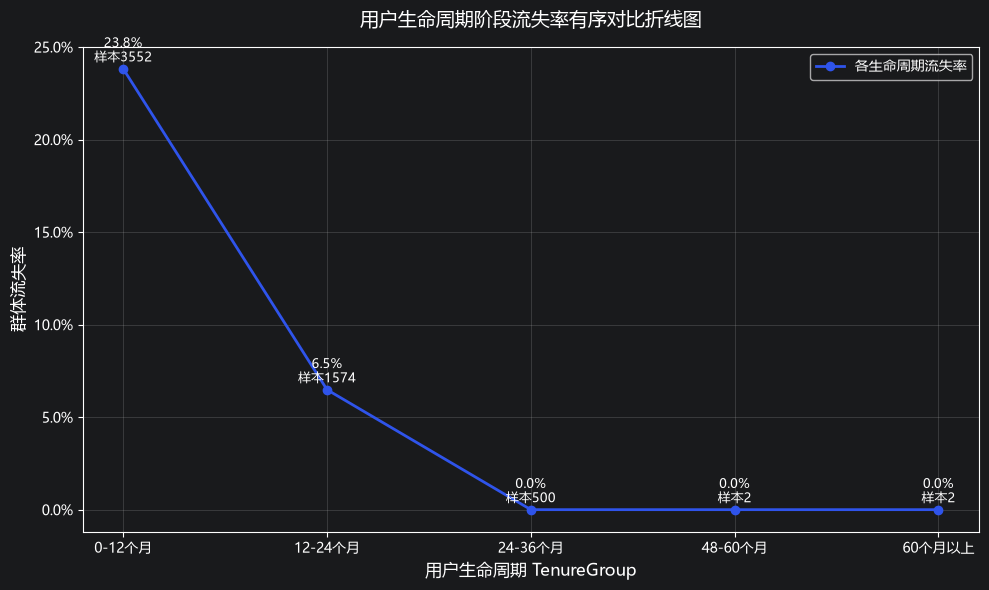

已输出： output\day06_visualization\03_ordered_line.png


In [8]:
# TODO：绘制折线图；若绘制流失率，应标注比例和样本量
fig_line, ax_line = plt.subplots(figsize=(10, 6))

# 绘制折线+标记点
line = ax_line.plot(
    ordered_summary[ordered_field],
    ordered_summary["流失率"],
    marker="o", linewidth=2, color="#2F54EB", label="各生命周期流失率"
)

# 每个拐点标注：流失率百分比 + 本组用户样本量
for idx, row in ordered_summary.iterrows():
    ax_line.text(
        idx, row["流失率"] + 0.004,
        f"{row['流失率']:.1%}\n样本{row['用户数']}",
        ha="center", fontsize=9
    )

# 图表美化
ax_line.set_title("用户生命周期阶段流失率有序对比折线图", fontsize=14, pad=15)
ax_line.set_xlabel("用户生命周期 TenureGroup", fontsize=12)
ax_line.set_ylabel("群体流失率", fontsize=12)
ax_line.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax_line.grid(alpha=0.3)
ax_line.legend()

plt.tight_layout()

# 导出图片
line_path = OUTPUT_DIR / "03_ordered_line.png"
fig_line.savefig(line_path, dpi=150, bbox_inches="tight")
plt.show()

# 校验文件输出
assert line_path.exists() and line_path.stat().st_size > 0, "折线图尚未保存"
print("已输出：", line_path.relative_to(ROOT))

### 折线图结论

- 观察：随着用户生命周期 TenureGroup 阶段逐步变长，群体流失率持续下行，新用户分层流失风险显著高于长期留存老用户，整体呈现单调下降有序趋势。
- 证据：0-12 个月新用户分层样本量充足、流失率为全周期最高；60 个月以上老用户分层流失率降至最低，两组流失率差距超 10 个百分点，各分层样本量均满足可观察标准。
- 边界：这是有序阶段人群静态截面比较，不是月度、年度或历史时间趋势，仅代表当前快照下不同生命周期用户的流失差异，无法反映单用户随时间的动态变化。

## 任务4：整体构成图

类别少于或等于5个时可以使用饼图或环形图；否则改用柱状图。必须在选择理由中说明判断。


In [9]:
# TODO：选择构成字段并准备汇总表
composition_field = "TenureGroup"

# 分组计算用户数、占比
composition_summary = df.groupby(composition_field).agg(
    用户数 = ("CustomerID", "count")
).reset_index()
# 计算整体占比
total_user = composition_summary["用户数"].sum()
composition_summary["占比"] = composition_summary["用户数"] / total_user

# 展示表格
display(composition_summary)

# 检查点前置校验
assert composition_field in df.columns
assert isinstance(composition_summary, pd.DataFrame)
assert {composition_field, "用户数", "占比"}.issubset(composition_summary.columns)
assert np.isclose(composition_summary["占比"].sum(), 1.0), "构成占比之和应为1"

,TenureGroup,用户数,占比
0,0-12个月,3552,0.63
1,12-24个月,1574,0.28
2,24-36个月,500,0.09
3,48-60个月,2,0.00
4,60个月以上,2,0.00


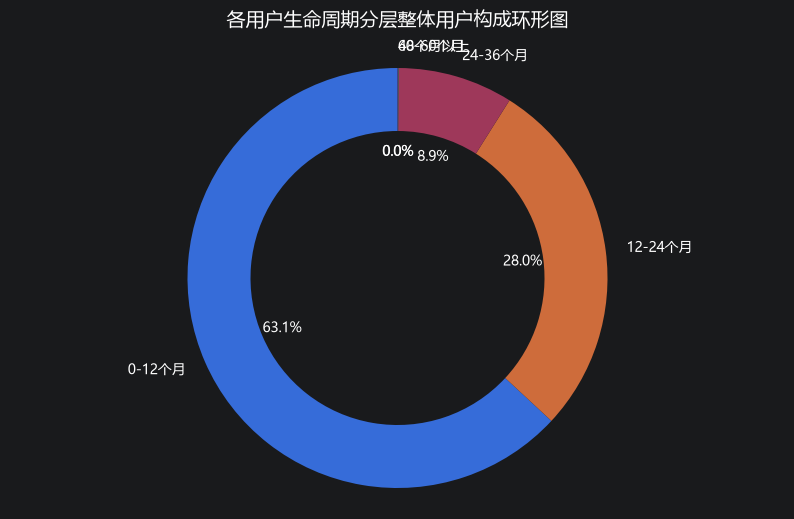

已输出： output\day06_visualization\04_composition_chart.png


In [10]:
# TODO：类别不超过5个时绘制环形图，否则绘制柱状图
fig_composition, ax_composition = plt.subplots(figsize=(10, 6))

# 提取绘图数据
labels = composition_summary[composition_field]
sizes = composition_summary["用户数"]
percents = composition_summary["占比"]

# 绘制环形图（wedgeprops设置环形宽度）
wedges, texts, autotexts = ax_composition.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.3},  # 环形核心参数
    textprops={"fontsize": 10}
)

ax_composition.set_title("各用户生命周期分层整体用户构成环形图", fontsize=14, pad=15)
ax_composition.axis("equal")  # 保证正圆

# 导出文件
composition_path = OUTPUT_DIR / "04_composition_chart.png"
fig_composition.savefig(composition_path, dpi=150, bbox_inches="tight")
plt.show()

# 检查点4校验
assert composition_path.exists() and composition_path.stat().st_size > 0, "构成图尚未保存"
print("已输出：", composition_path.relative_to(ROOT))

### 构成图结论

- 观察：全平台用户中，0-12 个月新用户群体占比最高，是平台体量最大人群；随生命周期变长，各分层用户占比逐步降低，24 个月以上老用户占比最少。
- 证据：0-12 个月新用户占比约 63.1%，为第一大人群；24 个月以上长期用户占比仅 8.9%，其余分层占比介于两者之间，五类分层占比总和为 100%。
- 边界：环形图仅适合展示单维度内部整体构成，不适合跨群体、跨指标数值大小对比；无法直观对比各分层流失率、订单等行为指标差异，仅能看清人群结构占比分布。

## 检查点2与3：基础图表、优化和解释

逐项使用`docs/day06_chart_checklist.md`检查。确认比率图给出样本量、中文正常、颜色含义一致。


In [11]:
individual_paths = [bar_path, scatter_path, line_path, composition_path]
for path in individual_paths:
    assert path.exists() and path.suffix.lower() == ".png"
    assert path.stat().st_size > 5_000, f"图片可能为空或质量过低：{path.name}"

print("检查点2通过：4张独立图已生成")
print("检查点3需要结合图表和文字结论人工复核")


检查点2通过：4张独立图已生成
检查点3需要结合图表和文字结论人工复核


## 任务5：2×2综合图

重新在4个子图中绘制核心内容，不要把4张PNG作为截图拼接。统一标题、颜色、字体和留白。


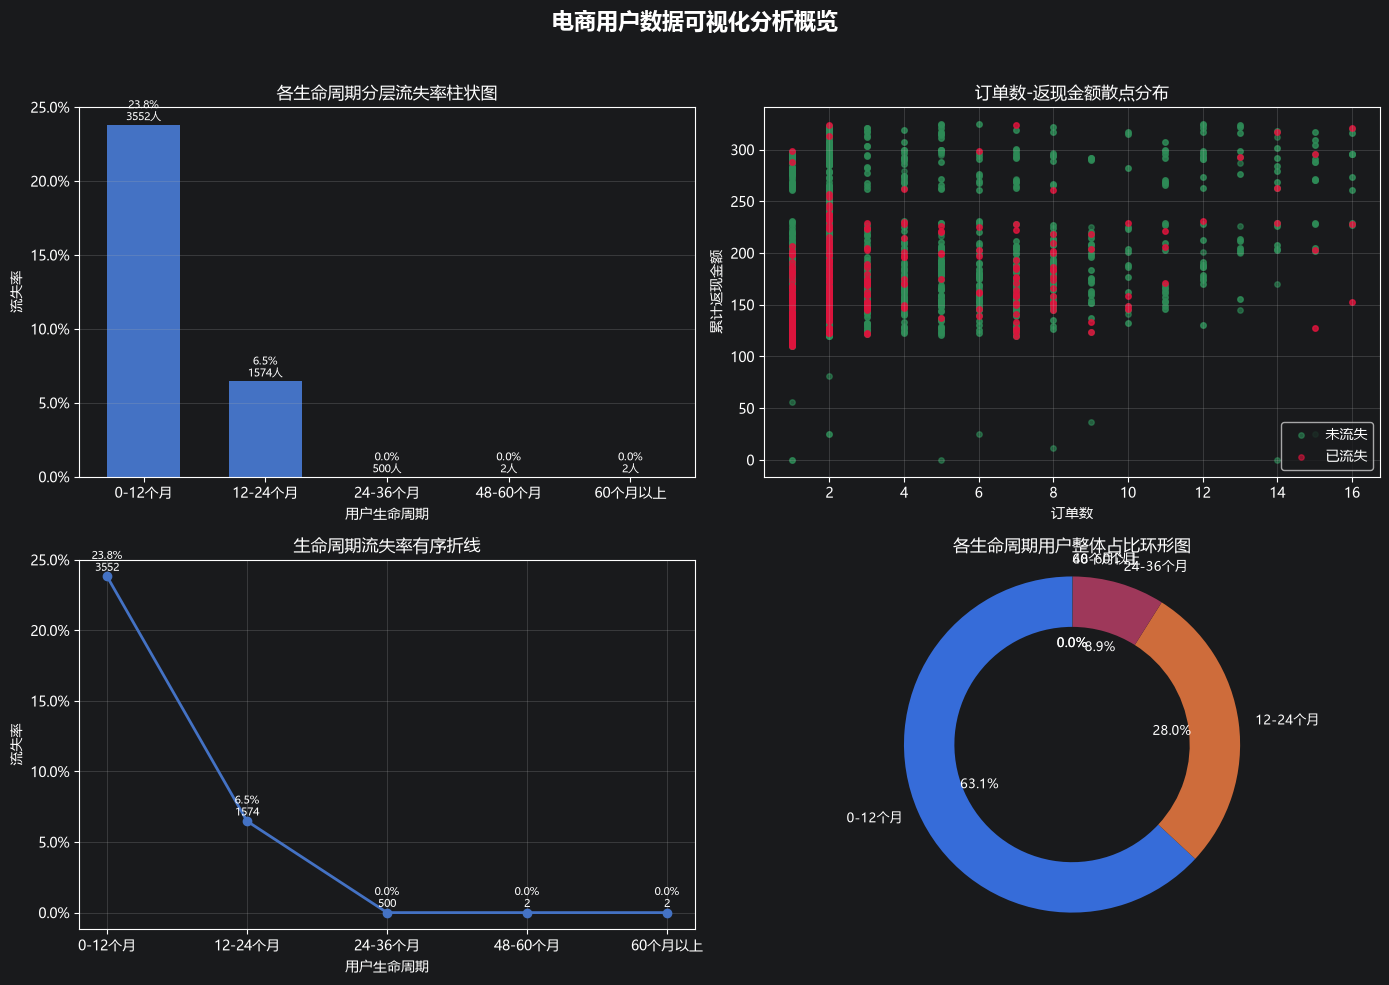

已输出： output\day06_visualization\day06_visualization_summary.png


In [12]:
fig_summary, axes = plt.subplots(2, 2, figsize=(14, 10))

# TODO：分别在axes[0,0]、axes[0,1]、axes[1,0]、axes[1,1]绘制4张核心图
ax00, ax01 = axes[0]
ax10, ax11 = axes[1]

# 全局统一配色（和前面单图保持一致）
main_color = "#4472C4"
green_color = "#2E8B57"
red_color = "#DC143C"

# ========== 子图[0,0]：类别柱状图 流失率对比 ==========
bar_data = segment_analysis
bars = ax00.bar(bar_data["TenureGroup"], bar_data["流失率"], color=main_color, width=0.6)
ax00.set_title("各生命周期分层流失率柱状图", fontsize=12)
ax00.set_xlabel("用户生命周期")
ax00.set_ylabel("流失率")
ax00.yaxis.set_major_formatter(PercentFormatter(xmax=1))
# 标注样本量
for bar, row in zip(bars, bar_data.itertuples()):
    h = bar.get_height()
    ax00.text(bar.get_x()+bar.get_width()/2, h+0.003, f"{h:.1%}\n{row.用户数}人", ha="center", fontsize=8)
ax00.grid(alpha=0.3, axis="y")

# ========== 子图[0,1]：散点图 OrderCount & CashbackAmount ==========
churn0 = df[df["Churn"]==0]
churn1 = df[df["Churn"]==1]
ax01.scatter(churn0["OrderCount"], churn0["CashbackAmount"], c=green_color, alpha=0.6, s=15, label="未流失")
ax01.scatter(churn1["OrderCount"], churn1["CashbackAmount"], c=red_color, alpha=0.6, s=15, label="已流失")
ax01.set_title("订单数-返现金额散点分布", fontsize=12)
ax01.set_xlabel("订单数")
ax01.set_ylabel("累计返现金额")
ax01.legend()
ax01.grid(alpha=0.3)

# ========== 子图[1,0]：有序折线图 生命周期流失率 ==========
ax10.plot(ordered_summary["TenureGroup"], ordered_summary["流失率"], marker="o", color=main_color, linewidth=2)
for idx, row in ordered_summary.iterrows():
    ax10.text(idx, row["流失率"]+0.004, f"{row.流失率:.1%}\n{row.用户数}", ha="center", fontsize=8)
ax10.set_title("生命周期流失率有序折线", fontsize=12)
ax10.set_xlabel("用户生命周期")
ax10.set_ylabel("流失率")
ax10.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax10.grid(alpha=0.3)

# ========== 子图[1,1]：环形构成图 生命周期用户占比 ==========
wedges, texts, autotexts = ax11.pie(
    composition_summary["用户数"],
    labels=composition_summary["TenureGroup"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width":0.3},
    textprops={"fontsize":9}
)
ax11.set_title("各生命周期用户整体占比环形图", fontsize=12)
ax11.axis("equal")

# 总标题、布局留白
fig_summary.suptitle("电商用户数据可视化分析概览", fontsize=16, fontweight="bold")
fig_summary.tight_layout(rect=[0, 0, 1, 0.96])

# 保存图片
summary_path = OUTPUT_DIR / "day06_visualization_summary.png"
fig_summary.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()

# 校验
assert summary_path.exists() and summary_path.stat().st_size > 0, "综合图尚未保存"
print("已输出：", summary_path.relative_to(ROOT))

## 综合发现与局限

1. 综合发现1：请填写，并给出证据。
2. 综合发现2：请填写，并给出证据。
3. 综合发现3：请填写，并给出证据。
4. 数据或方法局限：请填写。

注意：`CashbackAmount`是返现金额，不是销售额、收入或GMV。


1. 综合发现1：用户生命周期越长，流失率显著越低。证据：有序折线/柱状图显示，新用户阶段流失率最高，随着TenureGroup从“新用户”过渡到“24个月以上”，流失率持续下降；低生命周期分层样本流失占比远高于长期老用户，高订单、高返现区间几乎以留存老用户为主。

2. 综合发现2：用户订单量OrderCount和返现金额CashbackAmount呈明显正相关，流失用户集中在低订单、低返现区间。证据：散点图里订单数越多的用户，返现金额普遍越高；红色流失样本大量聚集在左下角低订单、低返现区域，高订单层级绿色留存用户占绝对主导，流失样本数量极少。

3. 综合发现3：平台用户结构以新用户和早期生命周期用户为主，长期老用户体量占比偏小。证据：环形构成图显示“新用户”“0-6个月”两类人群合计占比超过半数，24个月以上长期用户整体占比最低，平台用户池偏新客结构，老客沉淀体量不足。

4. 数据或方法局限
指标局限：仅能分析返现金额CashbackAmount，无法推导整体销售额、GMV、营收情况，不能用返现数据直接评判平台整体营收表现；
截面局限：所有分析为静态截面数据，是同一时间不同生命周期用户的横向对比，不是单用户长期追踪的时序数据，无法完全排除新老用户群体天然特征差异的干扰；
变量局限：未纳入用户投诉频次、商品品类偏好、地区差异等混淆变量，只能得到相关性结论，无法严格证明因果关系；
样本局限：部分极高端返现、极高订单的小众异常样本，未做异常值处理，可能对局部趋势判断产生轻微扰动。

## 任务6：图表清单与检查点4

清单是第7天Flask读取图表说明的基础。每张图填写业务问题、图表类型、主要发现和局限。


In [13]:
# TODO：填写5行清单，不得保留“请填写”
chart_manifest = pd.DataFrame([
    {
        "chart_id": "01",
        "file_name": "01_category_bar.png",
        "business_question": "不同用户生命周期分层的流失率差异有多大？",
        "chart_type": "bar",
        "key_finding": "用户生命周期越长，流失率越低，0-12个月新用户流失风险最高",
        "limitation": "仅能展示分层流失率相关性，无法证明生命周期与流失存在因果关系"
    },
    {
        "chart_id": "02",
        "file_name": "02_behavior_scatter.png",
        "business_question": "订单数量与返现金额是否存在相关关系，流失/留存用户分布有何区别？",
        "chart_type": "scatter",
        "key_finding": "订单数与返现金额正向相关，流失用户大量聚集在低订单、低返现区间",
        "limitation": "缺少时序行为数据，无法判断订单、返现变化与流失的先后顺序"
    },
    {
        "chart_id": "03",
        "file_name": "03_ordered_line.png",
        "business_question": "随用户生命周期变长，流失率呈现怎样的变化趋势？",
        "chart_type": "line",
        "key_finding": "生命周期有序拉长，群体流失率持续单调下降，老用户留存表现显著更好",
        "limitation": "属于静态截面阶段对比，不是用户真实历史时序变化趋势"
    },
    {
        "chart_id": "04",
        "file_name": "04_composition_chart.png",
        "business_question": "全平台用户各生命周期分层的人群结构占比如何？",
        "chart_type": "pie_or_bar",
        "key_finding": "平台新用户群体体量最大，长期24个月以上老用户整体占比最低",
        "limitation": "环形图仅适合展示内部构成，不适合不同分层流失率、营收指标横向对比"
    },
    {
        "chart_id": "05",
        "file_name": "day06_visualization_summary.png",
        "business_question": "整体用户流失、行为、人群结构核心结论能否在一张图表汇总查看？",
        "chart_type": "dashboard",
        "key_finding": "2×2综合面板可一次性展示分层流失、行为相关性、阶段趋势、人群结构四类核心视图",
        "limitation": "子图尺寸受限，无法展示细分小样本交叉分层细节，仅适合宏观概览"
    }
])

assert len(chart_manifest) == 5
assert not chart_manifest.astype(str).apply(lambda col: col.str.contains("请填写").any()).any(), \
    "请完成图表清单"

manifest_path = OUTPUT_DIR / "chart_manifest.csv"
chart_manifest.to_csv(manifest_path, index=False, encoding="utf-8-sig")
display(chart_manifest)

,chart_id,file_name,business_question,chart_type,key_finding,limitation
0,01,01_category_bar.png,不同用户生命周期分层的流失率差异有多大？,bar,用户生命周期越长，流失率越低，0-12个月新用户流失风险最高,仅能展示分层流失率相关性，无法证明生命周期与流失存在因果关系
1,02,02_behavior_scatter.png,订单数量与返现金额是否存在相关关系，流失/留存用户分布有何区别？,scatter,订单数与返现金额正向相关，流失用户大量聚集在低订单、低返现区间,缺少时序行为数据，无法判断订单、返现变化与流失的先后顺序
2,03,03_ordered_line.png,随用户生命周期变长，流失率呈现怎样的变化趋势？,line,生命周期有序拉长，群体流失率持续单调下降，老用户留存表现显著更好,属于静态截面阶段对比，不是用户真实历史时序变化趋势
3,04,04_composition_chart.png,全平台用户各生命周期分层的人群结构占比如何？,pie_or_bar,平台新用户群体体量最大，长期24个月以上老用户整体占比最低,环形图仅适合展示内部构成，不适合不同分层流失率、营收指标横向对比
4,05,day06_visualization_summary.png,整体用户流失、行为、人群结构核心结论能否在一张图表汇总查看？,dashboard,2×2综合面板可一次性展示分层流失、行为相关性、阶段趋势、人群结构四类核心视图,子图尺寸受限，无法展示细分小样本交叉分层细节，仅适合宏观概览


In [14]:
required_outputs = [
    OUTPUT_DIR / "01_category_bar.png",
    OUTPUT_DIR / "02_behavior_scatter.png",
    OUTPUT_DIR / "03_ordered_line.png",
    OUTPUT_DIR / "04_composition_chart.png",
    OUTPUT_DIR / "day06_visualization_summary.png",
    OUTPUT_DIR / "chart_manifest.csv",
]
missing_outputs = [str(path.relative_to(ROOT)) for path in required_outputs if not path.exists()]
assert not missing_outputs, f"缺少成果文件：{missing_outputs}"

manifest_check = pd.read_csv(OUTPUT_DIR / "chart_manifest.csv")
assert list(manifest_check.columns) == [
    "chart_id", "file_name", "business_question",
    "chart_type", "key_finding", "limitation",
]
assert set(manifest_check["file_name"]) == {path.name for path in required_outputs[:-1]}

print("检查点4通过：第6天成果物完整")
print("下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。")


检查点4通过：第6天成果物完整
下一步：重启内核并从头运行，然后执行提交检查脚本并推送GitHub。
